Train: (630000, 21) | Test: (270000, 20)

Target distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Target proportions:
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64

Encoding: {np.str_('High'): 0, np.str_('Low'): 1, np.str_('Medium'): 2}

Features: 35 (8 cat, 11 num, 16 engineered)
Classes: 3 -> [np.str_('High'), np.str_('Low'), np.str_('Medium')]

=== LightGBM ===
Training until validation scores don't improve for 100 rounds
[500]	valid_0's multi_logloss: 0.0586645
Early stopping, best iteration is:
[668]	valid_0's multi_logloss: 0.0583652
  Fold 1: balanced_acc = 0.96038
Training until validation scores don't improve for 100 rounds
[500]	valid_0's multi_logloss: 0.0594971
Early stopping, best iteration is:
[668]	valid_0's multi_logloss: 0.0592836
  Fold 2: balanced_acc = 0.96185
Training until validation scores don't improve for 100 rounds
[500]	valid_0's multi_loglos

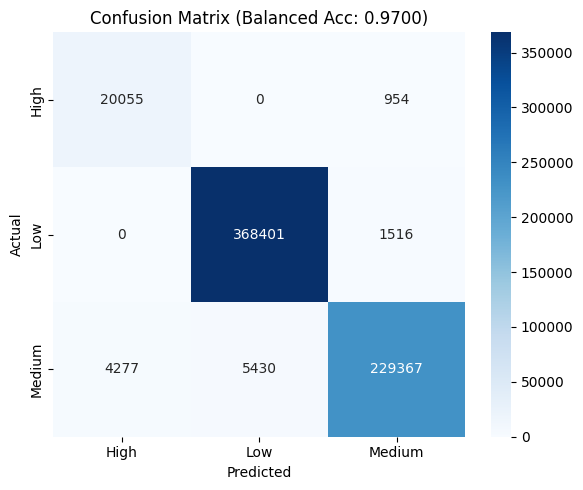

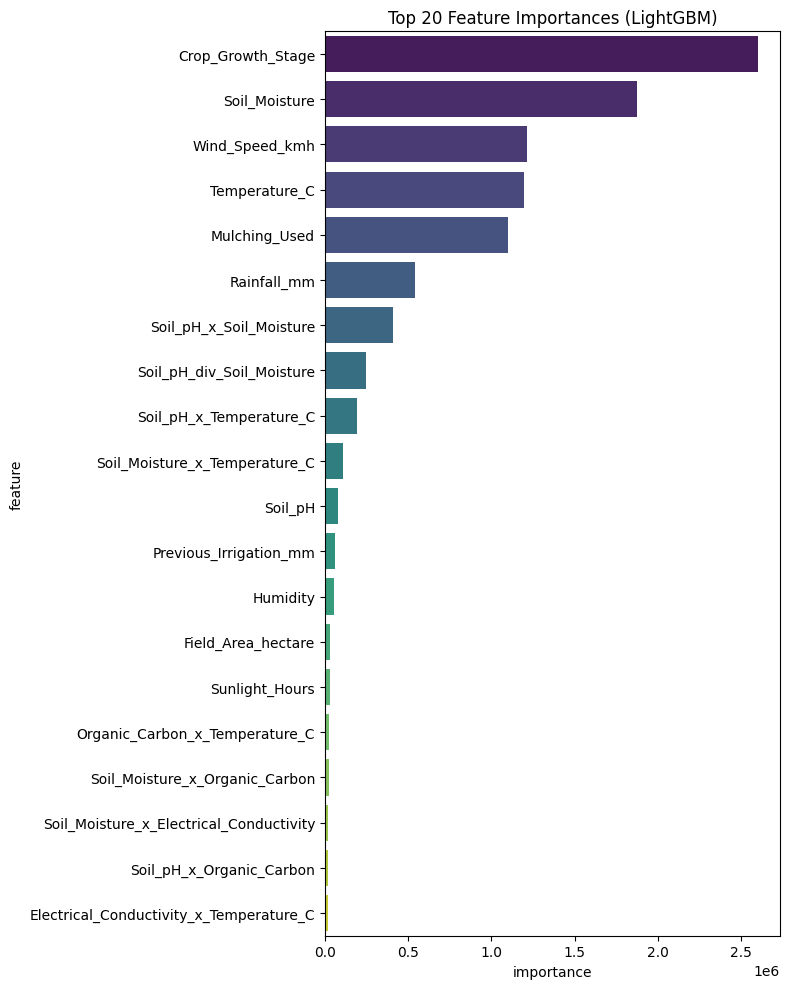


Submission saved! Shape: (270000, 2)
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008            High
9  630009             Low

Prediction distribution:
Irrigation_Need
Low       0.592741
Medium    0.368515
High      0.038744
Name: proportion, dtype: float64

Done! Submit submission.csv for your Day 2 score.


In [1]:
# =============================================================================
# Predicting Irrigation Need — Day 2: Balanced Accuracy Optimization
# Kaggle Playground Series S6E4 | Author: Dean Wang (deanbatur)
# =============================================================================
# Day 1: Baseline LGB + XGB ensemble
# Day 2: Optimize for balanced accuracy metric + threshold tuning + CatBoost
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from scipy.optimize import minimize
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# --- 1. LOAD DATA ---
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')

target_col = 'Irrigation_Need'
id_col = 'id'
class_names = ['High', 'Low', 'Medium']  # alphabetical from LabelEncoder

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"\nTarget distribution:\n{train[target_col].value_counts()}")
print(f"\nTarget proportions:\n{train[target_col].value_counts(normalize=True)}")

# --- 2. ENCODE TARGET ---
target_le = LabelEncoder()
target_le.fit(class_names)
train[target_col] = target_le.transform(train[target_col].astype(str))
print(f"\nEncoding: {dict(zip(target_le.classes_, range(len(target_le.classes_))))}")

# --- 3. FEATURE ENGINEERING ---
feature_cols = [c for c in train.columns if c not in [id_col, target_col]]
cat_cols = train[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train[feature_cols].select_dtypes(include=['number']).columns.tolist()

# Save original cat cols for CatBoost (before encoding)
cat_col_indices = []

# Label encode categorical features
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    le_dict[col] = le

# Interaction features (top 5 numeric pairs)
if len(num_cols) >= 2:
    for i in range(min(len(num_cols), 5)):
        for j in range(i+1, min(len(num_cols), 5)):
            c1, c2 = num_cols[i], num_cols[j]
            train[f'{c1}_x_{c2}'] = train[c1] * train[c2]
            test[f'{c1}_x_{c2}'] = test[c1] * test[c2]

# Ratio features (avoid division by zero)
if len(num_cols) >= 2:
    for i in range(min(len(num_cols), 4)):
        for j in range(i+1, min(len(num_cols), 4)):
            c1, c2 = num_cols[i], num_cols[j]
            train[f'{c1}_div_{c2}'] = train[c1] / (train[c2] + 1e-8)
            test[f'{c1}_div_{c2}'] = test[c1] / (test[c2] + 1e-8)

feature_cols = [c for c in train.columns if c not in [id_col, target_col]]
# Track which columns are categorical (by index) for CatBoost
cat_col_indices = [feature_cols.index(c) for c in cat_cols if c in feature_cols]

print(f"\nFeatures: {len(feature_cols)} ({len(cat_cols)} cat, {len(num_cols)} num, {len(feature_cols) - len(cat_cols) - len(num_cols)} engineered)")

# --- 4. PREPARE ---
X = train[feature_cols].values
y = train[target_col].values
X_test = test[feature_cols].values
test_ids = test[id_col].values

n_classes = len(np.unique(y))
print(f"Classes: {n_classes} -> {list(target_le.classes_)}")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# =============================================================================
# --- 5. LIGHTGBM (optimized for balanced accuracy) ---
# =============================================================================
lgb_oof_probs = np.zeros((len(X), n_classes))
lgb_test_probs = np.zeros((len(X_test), n_classes))
lgb_scores = []

lgb_params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 95,
    'max_depth': 8,
    'min_child_samples': 15,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.75,
    'bagging_freq': 5,
    'lambda_l1': 0.05,
    'lambda_l2': 0.1,
    'num_class': n_classes,
    'is_unbalance': True,
    'verbosity': -1,
    'n_jobs': -1,
    'random_state': 42,
}

print("\n=== LightGBM ===")
lgb_model = None
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    lgb_model = lgb.train(
        lgb_params, dtrain, num_boost_round=3000, valid_sets=[dval],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
    )
    lgb_oof_probs[val_idx] = lgb_model.predict(X_val)
    lgb_test_probs += lgb_model.predict(X_test) / N_FOLDS
    score = balanced_accuracy_score(y_val, lgb_oof_probs[val_idx].argmax(axis=1))
    lgb_scores.append(score)
    print(f"  Fold {fold+1}: balanced_acc = {score:.5f}")
print(f"LightGBM CV (balanced acc): {np.mean(lgb_scores):.5f} +/- {np.std(lgb_scores):.5f}")

# =============================================================================
# --- 6. XGBOOST ---
# =============================================================================
xgb_oof_probs = np.zeros((len(X), n_classes))
xgb_test_probs = np.zeros((len(X_test), n_classes))
xgb_scores = []

print("\n=== XGBoost ===")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # Compute sample weights for balanced accuracy
    class_counts = np.bincount(y_tr)
    sample_weights = np.array([1.0 / class_counts[c] for c in y_tr])
    sample_weights = sample_weights / sample_weights.sum() * len(y_tr)
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=3000, learning_rate=0.03, max_depth=7,
        min_child_weight=5, subsample=0.75, colsample_bytree=0.75,
        reg_alpha=0.05, reg_lambda=0.1,
        objective='multi:softprob', num_class=n_classes,
        eval_metric='mlogloss', tree_method='hist',
        random_state=42, n_jobs=-1, early_stopping_rounds=100, verbosity=0
    )
    xgb_model.fit(X_tr, y_tr, sample_weight=sample_weights,
                  eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof_probs[val_idx] = xgb_model.predict_proba(X_val)
    xgb_test_probs += xgb_model.predict_proba(X_test) / N_FOLDS
    score = balanced_accuracy_score(y_val, xgb_oof_probs[val_idx].argmax(axis=1))
    xgb_scores.append(score)
    print(f"  Fold {fold+1}: balanced_acc = {score:.5f}")
print(f"XGBoost CV (balanced acc): {np.mean(xgb_scores):.5f} +/- {np.std(xgb_scores):.5f}")

# =============================================================================
# --- 7. CATBOOST ---
# =============================================================================
cb_oof_probs = np.zeros((len(X), n_classes))
cb_test_probs = np.zeros((len(X_test), n_classes))
cb_scores = []

print("\n=== CatBoost ===")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    cb_model = CatBoostClassifier(
        iterations=3000, learning_rate=0.03, depth=8,
        l2_leaf_reg=3, auto_class_weights='Balanced',
        eval_metric='TotalF1', loss_function='MultiClass',
        random_seed=42, verbose=0, early_stopping_rounds=100
    )
    cb_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    cb_oof_probs[val_idx] = cb_model.predict_proba(X_val)
    cb_test_probs += cb_model.predict_proba(X_test) / N_FOLDS
    score = balanced_accuracy_score(y_val, cb_oof_probs[val_idx].argmax(axis=1))
    cb_scores.append(score)
    print(f"  Fold {fold+1}: balanced_acc = {score:.5f}")
print(f"CatBoost CV (balanced acc): {np.mean(cb_scores):.5f} +/- {np.std(cb_scores):.5f}")

# =============================================================================
# --- 8. THRESHOLD TUNING ON OOF PROBABILITIES ---
# =============================================================================
print("\n=== Threshold Tuning ===")

# Blend OOF probabilities from all 3 models
# Try different blend weights and pick the best
best_blend_score = 0
best_weights = (1/3, 1/3, 1/3)

for w1 in np.arange(0.1, 0.8, 0.1):
    for w2 in np.arange(0.1, 0.8 - w1, 0.1):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05:
            continue
        blend = w1 * lgb_oof_probs + w2 * xgb_oof_probs + w3 * cb_oof_probs
        score = balanced_accuracy_score(y, blend.argmax(axis=1))
        if score > best_blend_score:
            best_blend_score = score
            best_weights = (round(w1, 2), round(w2, 2), round(w3, 2))

print(f"Best blend weights: LGB={best_weights[0]}, XGB={best_weights[1]}, CB={best_weights[2]}")
print(f"Best blend balanced acc (before threshold): {best_blend_score:.5f}")

# Blend with best weights
oof_probs = best_weights[0] * lgb_oof_probs + best_weights[1] * xgb_oof_probs + best_weights[2] * cb_oof_probs
test_probs = best_weights[0] * lgb_test_probs + best_weights[1] * xgb_test_probs + best_weights[2] * cb_test_probs

# Now tune per-class thresholds to maximize balanced accuracy
# We adjust the probability of each class by a multiplier, then take argmax
def objective(multipliers):
    adjusted = oof_probs * multipliers
    preds = adjusted.argmax(axis=1)
    return -balanced_accuracy_score(y, preds)  # negative because we minimize

# Start with equal multipliers
x0 = np.ones(n_classes)
result = minimize(objective, x0, method='Nelder-Mead',
                  options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6})
best_multipliers = result.x
tuned_score = -result.fun

print(f"\nClass multipliers: {dict(zip(target_le.classes_, best_multipliers.round(4)))}")
print(f"Balanced acc AFTER threshold tuning: {tuned_score:.5f}")
print(f"Improvement from tuning: +{tuned_score - best_blend_score:.5f}")

# --- 9. COMPARE ALL APPROACHES ---
print("\n=== Summary ===")
print(f"LightGBM alone:           {np.mean(lgb_scores):.5f}")
print(f"XGBoost alone:            {np.mean(xgb_scores):.5f}")
print(f"CatBoost alone:           {np.mean(cb_scores):.5f}")
print(f"Best blend (no tuning):   {best_blend_score:.5f}")
print(f"Best blend + thresholds:  {tuned_score:.5f}")

# Confusion matrix on OOF
adjusted_oof = oof_probs * best_multipliers
oof_preds = adjusted_oof.argmax(axis=1)
print(f"\nClassification Report (OOF):")
print(classification_report(y, oof_preds, target_names=target_le.classes_))

cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Balanced Acc: {tuned_score:.4f})')
plt.tight_layout()
plt.show()

# --- 10. FEATURE IMPORTANCE ---
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, max(6, min(len(feature_cols), 20) // 2)))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

# --- 11. SUBMIT ---
adjusted_test = test_probs * best_multipliers
final_preds = adjusted_test.argmax(axis=1)
submission = pd.DataFrame({id_col: test_ids, target_col: target_le.inverse_transform(final_preds)})

submission.to_csv('submission.csv', index=False)
print(f"\nSubmission saved! Shape: {submission.shape}")
print(submission.head(10))
print(f"\nPrediction distribution:\n{submission[target_col].value_counts(normalize=True)}")
print(f"\nDone! Submit submission.csv for your Day 2 score.")